In [24]:
# ================================
# CELL 1: INSTALL & IMPORT
# ================================

!pip install -q tensorflow scikit-learn pandas numpy matplotlib seaborn

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf

from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense, Dropout, Input
from tensorflow.keras.optimizers import Adam

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.base import BaseEstimator, ClassifierMixin
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

print("TensorFlow:", tf.__version__)
print("Libraries loaded successfully!")

TensorFlow: 2.20.0
Libraries loaded successfully!


In [25]:
# ================================
# CELL 2: LOAD DATASET
# ================================

url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/pima-indians-diabetes.data.csv"

columns = [
    "Pregnancies",
    "Glucose",
    "BloodPressure",
    "SkinThickness",
    "Insulin",
    "BMI",
    "DiabetesPedigreeFunction",
    "Age",
    "Outcome"
]

df = pd.read_csv(url, names=columns)

print("Dataset Shape:", df.shape)
print("\nFirst 5 rows:")
display(df.head())

print("\nClass Distribution:")
print(df["Outcome"].value_counts())

print("\nClass Percentage:")
print(df["Outcome"].value_counts(normalize=True) * 100)

Dataset Shape: (768, 9)

First 5 rows:


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1



Class Distribution:
Outcome
0    500
1    268
Name: count, dtype: int64

Class Percentage:
Outcome
0    65.104167
1    34.895833
Name: proportion, dtype: float64


**Data exploration and class balance**

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB

Statistical Summary:


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


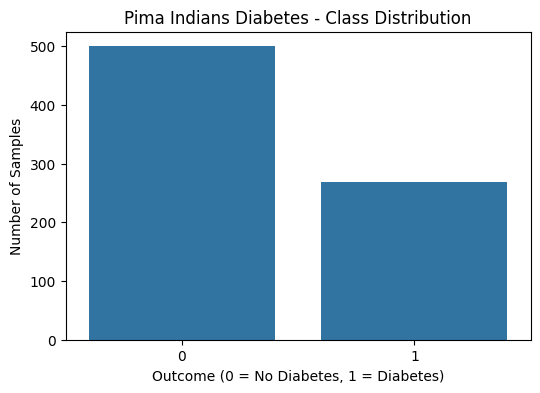

10 Random Samples:


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
668,6,98,58,33,190,34.0,0.430,43,0
324,2,112,75,32,0,35.7,0.148,21,0
624,2,108,64,0,0,30.8,0.158,21,0
690,8,107,80,0,0,24.6,0.856,34,0
473,7,136,90,0,0,29.9,0.210,50,0
204,6,103,72,32,190,37.7,0.324,55,0
97,1,71,48,18,76,20.4,0.323,22,0
336,0,117,0,0,0,33.8,0.932,44,0
568,4,154,72,29,126,31.3,0.338,37,0
148,5,147,78,0,0,33.7,0.218,65,0


In [26]:
# ================================
# CELL 3: EXPLORATION
# ================================

print("Dataset Information:")
df.info()

print("\nStatistical Summary:")
display(df.describe())

# Class balance
plt.figure(figsize=(6, 4))

sns.countplot(
    data=df,
    x="Outcome"
)

plt.title("Pima Indians Diabetes - Class Distribution")
plt.xlabel("Outcome (0 = No Diabetes, 1 = Diabetes)")
plt.ylabel("Number of Samples")
plt.show()

# Random samples
print("10 Random Samples:")
display(df.sample(10, random_state=42))

**Preprocessing and train/validation/test split**






In [27]:
# ================================
# CELL 4: PREPROCESSING
# ================================

X = df.drop("Outcome", axis=1).copy()
y = df["Outcome"].astype(int)

# In this dataset, zero values in these columns represent
# missing/invalid measurements.
zero_columns = [
    "Glucose",
    "BloodPressure",
    "SkinThickness",
    "Insulin",
    "BMI"
]

# Replace zeros with NaN
X[zero_columns] = X[zero_columns].replace(0, np.nan)

# Fill missing values with median
for column in zero_columns:
    X[column] = X[column].fillna(X[column].median())

# --------------------------------
# 70% TRAINING
# 30% TEMPORARY
# --------------------------------

X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=42,
    stratify=y
)

# --------------------------------
# 15% VALIDATION
# 15% TESTING
# --------------------------------

X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    random_state=42,
    stratify=y_temp
)

# --------------------------------
# FEATURE SCALING
# --------------------------------

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test)

print("Training:", X_train.shape)
print("Validation:", X_val.shape)
print("Testing:", X_test.shape)

Training: (537, 8)
Validation: (115, 8)
Testing: (116, 8)


Create the deep learning model

In [28]:
# ================================
# CELL 5: CUSTOM KERAS CLASSIFIER
# ================================

class KerasDiabetesClassifier(BaseEstimator, ClassifierMixin):

    def __init__(
        self,
        batch_size=32,
        epochs=20,
        learning_rate=0.001,
        kernel_initializer="glorot_uniform",
        activation="relu",
        dropout_rate=0.2,
        neurons=32
    ):

        self.batch_size = batch_size
        self.epochs = epochs
        self.learning_rate = learning_rate
        self.kernel_initializer = kernel_initializer
        self.activation = activation
        self.dropout_rate = dropout_rate
        self.neurons = neurons

    def build_model(self, input_features):

        model = Sequential([
            Input(shape=(input_features,)),

            Dense(
                self.neurons,
                activation=self.activation,
                kernel_initializer=self.kernel_initializer
            ),

            Dropout(self.dropout_rate),

            Dense(
                16,
                activation=self.activation,
                kernel_initializer=self.kernel_initializer
            ),

            Dropout(self.dropout_rate),

            Dense(
                1,
                activation="sigmoid"
            )
        ])

        optimizer = Adam(
            learning_rate=self.learning_rate
        )

        model.compile(
            optimizer=optimizer,
            loss="binary_crossentropy",
            metrics=["accuracy"]
        )

        return model

    def fit(self, X, y):

        # Store number of features
        self.n_features_in_ = X.shape[1]

        # Required by sklearn classifier
        self.classes_ = np.unique(y)

        # Build model
        self.model_ = self.build_model(
            self.n_features_in_
        )

        # Train
        self.model_.fit(
            X,
            y,
            batch_size=self.batch_size,
            epochs=self.epochs,
            verbose=0
        )

        return self

    def predict(self, X):

        probability = self.model_.predict(
            X,
            verbose=0
        ).ravel()

        return (probability >= 0.5).astype(int)

    def predict_proba(self, X):

        probability = self.model_.predict(
            X,
            verbose=0
        ).ravel()

        return np.column_stack(
            [
                1 - probability,
                probability
            ]
        )

In [29]:
# ================================
# CELL 6: TEST MODEL
# ================================

test_model = KerasDiabetesClassifier(
    batch_size=32,
    epochs=5,
    learning_rate=0.001,
    activation="relu",
    neurons=32,
    dropout_rate=0.2
)

test_model.fit(X_train, y_train)

test_prediction = test_model.predict(X_test)

print("Test model accuracy:",
      round(accuracy_score(y_test, test_prediction), 4))

print("Model is working correctly!")

Test model accuracy: 0.7155
Model is working correctly!


In [31]:
param_grid = {
    "batch_size": [16, 32],
    "epochs": [20],
    "learning_rate": [0.001, 0.01],
    "kernel_initializer": ["glorot_uniform", "he_uniform"],
    "activation": ["relu", "tanh"],
    "dropout_rate": [0.2],
    "neurons": [32, 64]
}

In [33]:
# ============================================================
# COMPLETE DEEP LEARNING GRID SEARCH
# PIMA INDIANS DIABETES
# ============================================================

import numpy as np
import pandas as pd
import tensorflow as tf

from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense, Dropout, Input
from tensorflow.keras.optimizers import Adam

from sklearn.base import BaseEstimator, ClassifierMixin
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score, classification_report


# ============================================================
# 1. CREATE SCIKIT-LEARN COMPATIBLE KERAS CLASSIFIER
# ============================================================

class DiabetesClassifier(BaseEstimator, ClassifierMixin):

    def __init__(
        self,
        batch_size=32,
        epochs=20,
        learning_rate=0.001,
        kernel_initializer="glorot_uniform",
        activation="relu",
        dropout_rate=0.2,
        neurons=32
    ):
        self.batch_size = batch_size
        self.epochs = epochs
        self.learning_rate = learning_rate
        self.kernel_initializer = kernel_initializer
        self.activation = activation
        self.dropout_rate = dropout_rate
        self.neurons = neurons

    def _create_model(self, n_features):

        model = Sequential([
            Input(shape=(n_features,)),

            Dense(
                self.neurons,
                activation=self.activation,
                kernel_initializer=self.kernel_initializer
            ),

            Dropout(self.dropout_rate),

            Dense(
                16,
                activation=self.activation,
                kernel_initializer=self.kernel_initializer
            ),

            Dropout(self.dropout_rate),

            Dense(
                1,
                activation="sigmoid"
            )
        ])

        model.compile(
            optimizer=Adam(
                learning_rate=self.learning_rate
            ),
            loss="binary_crossentropy",
            metrics=["accuracy"]
        )

        return model

    def fit(self, X, y):

        self.classes_ = np.unique(y)
        self.n_features_in_ = X.shape[1]

        self.model_ = self._create_model(
            self.n_features_in_
        )

        self.model_.fit(
            X,
            y,
            epochs=self.epochs,
            batch_size=self.batch_size,
            verbose=0
        )

        return self

    def predict(self, X):

        probabilities = self.model_.predict(
            X,
            verbose=0
        ).ravel()

        return (probabilities >= 0.5).astype(int)

    def predict_proba(self, X):

        probabilities = self.model_.predict(
            X,
            verbose=0
        ).ravel()

        return np.column_stack([
            1 - probabilities,
            probabilities
        ])


# ============================================================
# 2. SMALL GRID FOR FAST EXECUTION
# ============================================================

param_grid = {

    "batch_size": [16, 32],

    "epochs": [20],

    "learning_rate": [0.001, 0.01],

    "kernel_initializer": [
        "glorot_uniform",
        "he_uniform"
    ],

    "activation": [
        "relu",
        "tanh"
    ],

    "dropout_rate": [
        0.2
    ],

    "neurons": [
        32,
        64
    ]
}


# ============================================================
# 3. CREATE GRID SEARCH
# ============================================================

model = DiabetesClassifier()

grid = GridSearchCV(
    estimator=model,
    param_grid=param_grid,
    scoring="accuracy",
    cv=3,
    n_jobs=1,
    verbose=1
)


# ============================================================
# 4. RUN GRID SEARCH
# ============================================================

print("=" * 60)
print("STARTING GRID SEARCH")
print("=" * 60)
print()
print("Please wait...")
print()

grid_result = grid.fit(
    X_train,
    y_train
)


# ============================================================
# 5. DISPLAY BEST RESULTS
# ============================================================

print()
print("=" * 60)
print("GRID SEARCH COMPLETED")
print("=" * 60)

print(
    "\nBest Cross-Validation Accuracy:",
    round(grid_result.best_score_, 4)
)

print("\nBest Hyperparameters:")

for parameter, value in grid_result.best_params_.items():
    print(f"{parameter}: {value}")


# ============================================================
# 6. VALIDATION & TESTING
# ============================================================

best_model = grid_result.best_estimator_

validation_prediction = best_model.predict(X_val)
test_prediction = best_model.predict(X_test)

validation_accuracy = accuracy_score(
    y_val,
    validation_prediction
)

test_accuracy = accuracy_score(
    y_test,
    test_prediction
)

print(
    "\nValidation Accuracy:",
    round(validation_accuracy, 4)
)

print(
    "Test Accuracy:",
    round(test_accuracy, 4)
)


# ============================================================
# 7. CLASSIFICATION REPORT
# ============================================================

print("\nClassification Report:")
print(
    classification_report(
        y_test,
        test_prediction,
        target_names=[
            "No Diabetes",
            "Diabetes"
        ]
    )
)


# ============================================================
# 8. SAVE GRID SEARCH RESULTS
# ============================================================

results = pd.DataFrame(
    grid_result.cv_results_
)

results = results.sort_values(
    "mean_test_score",
    ascending=False
)

print("\nTop 10 Grid Search Results:")

display(
    results[
        [
            "mean_test_score",
            "param_batch_size",
            "param_epochs",
            "param_learning_rate",
            "param_kernel_initializer",
            "param_activation",
            "param_dropout_rate",
            "param_neurons"
        ]
    ].head(10)
)

STARTING GRID SEARCH

Please wait...

Fitting 3 folds for each of 32 candidates, totalling 96 fits

GRID SEARCH COMPLETED

Best Cross-Validation Accuracy: 0.7784

Best Hyperparameters:
activation: tanh
batch_size: 16
dropout_rate: 0.2
epochs: 20
kernel_initializer: glorot_uniform
learning_rate: 0.001
neurons: 32

Validation Accuracy: 0.7217
Test Accuracy: 0.7586

Classification Report:
              precision    recall  f1-score   support

 No Diabetes       0.78      0.88      0.82        75
    Diabetes       0.71      0.54      0.61        41

    accuracy                           0.76       116
   macro avg       0.74      0.71      0.72       116
weighted avg       0.75      0.76      0.75       116


Top 10 Grid Search Results:


,mean_test_score,param_batch_size,param_epochs,param_learning_rate,param_kernel_initializer,param_activation,param_dropout_rate,param_neurons
16,0.778399,16,20,0.001,glorot_uniform,tanh,0.2,32
25,0.776536,32,20,0.001,glorot_uniform,tanh,0.2,64
17,0.772812,16,20,0.001,glorot_uniform,tanh,0.2,64
19,0.772812,16,20,0.010,glorot_uniform,tanh,0.2,64
24,0.772812,32,20,0.001,glorot_uniform,tanh,0.2,32
8,0.770950,32,20,0.001,glorot_uniform,relu,0.2,32
28,0.767225,32,20,0.001,he_uniform,tanh,0.2,32
1,0.767225,16,20,0.001,glorot_uniform,relu,0.2,64
6,0.765363,16,20,0.010,he_uniform,relu,0.2,32
13,0.763501,32,20,0.001,he_uniform,relu,0.2,64


In [34]:
# ================================
# CELL 8: BEST PARAMETERS
# ================================

print("=" * 60)
print("BEST GRID SEARCH RESULTS")
print("=" * 60)

print(
    "\nBest Cross-Validation Accuracy:",
    round(grid_result.best_score_, 4)
)

print("\nBest Hyperparameters:")

for parameter, value in grid_result.best_params_.items():
    print(f"{parameter}: {value}")

BEST GRID SEARCH RESULTS

Best Cross-Validation Accuracy: 0.7784

Best Hyperparameters:
activation: tanh
batch_size: 16
dropout_rate: 0.2
epochs: 20
kernel_initializer: glorot_uniform
learning_rate: 0.001
neurons: 32


In [35]:
# ================================
# CELL 9: FINAL EVALUATION
# ================================

best_model = grid_result.best_estimator_

# Validation prediction
validation_prediction = best_model.predict(X_val)

# Test prediction
test_prediction = best_model.predict(X_test)

validation_accuracy = accuracy_score(
    y_val,
    validation_prediction
)

test_accuracy = accuracy_score(
    y_test,
    test_prediction
)

print("Validation Accuracy:",
      round(validation_accuracy, 4))

print("Test Accuracy:",
      round(test_accuracy, 4))

print("\nClassification Report:")
print(
    classification_report(
        y_test,
        test_prediction,
        target_names=[
            "No Diabetes",
            "Diabetes"
        ]
    )
)

Validation Accuracy: 0.7217
Test Accuracy: 0.7586

Classification Report:
              precision    recall  f1-score   support

 No Diabetes       0.78      0.88      0.82        75
    Diabetes       0.71      0.54      0.61        41

    accuracy                           0.76       116
   macro avg       0.74      0.71      0.72       116
weighted avg       0.75      0.76      0.75       116



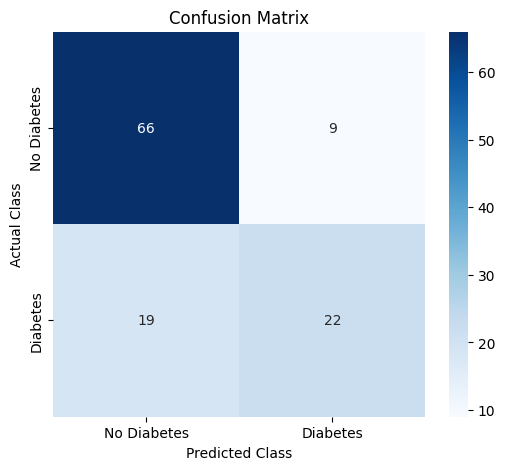

In [36]:
# ================================
# CELL 10: CONFUSION MATRIX
# ================================

cm = confusion_matrix(
    y_test,
    test_prediction
)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=[
        "No Diabetes",
        "Diabetes"
    ],
    yticklabels=[
        "No Diabetes",
        "Diabetes"
    ]
)

plt.title("Confusion Matrix")
plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")

plt.show()

In [37]:
# ================================
# CELL 11: GRID SEARCH RESULTS
# ================================

results = pd.DataFrame(
    grid_result.cv_results_
)

results = results.sort_values(
    by="mean_test_score",
    ascending=False
)

display(
    results[
        [
            "mean_test_score",
            "std_test_score",
            "param_batch_size",
            "param_epochs",
            "param_learning_rate",
            "param_kernel_initializer",
            "param_activation",
            "param_dropout_rate",
            "param_neurons"
        ]
    ].head(10)
)

,mean_test_score,std_test_score,param_batch_size,param_epochs,param_learning_rate,param_kernel_initializer,param_activation,param_dropout_rate,param_neurons
16,0.778399,0.021556,16,20,0.001,glorot_uniform,tanh,0.2,32
25,0.776536,0.019883,32,20,0.001,glorot_uniform,tanh,0.2,64
17,0.772812,0.017269,16,20,0.001,glorot_uniform,tanh,0.2,64
19,0.772812,0.005267,16,20,0.010,glorot_uniform,tanh,0.2,64
24,0.772812,0.022501,32,20,0.001,glorot_uniform,tanh,0.2,32
8,0.770950,0.012068,32,20,0.001,glorot_uniform,relu,0.2,32
28,0.767225,0.017269,32,20,0.001,he_uniform,tanh,0.2,32
1,0.767225,0.013935,16,20,0.001,glorot_uniform,relu,0.2,64
6,0.765363,0.009123,16,20,0.010,he_uniform,relu,0.2,32
13,0.763501,0.021556,32,20,0.001,he_uniform,relu,0.2,64


In [38]:
# ================================
# CELL 12: FINAL SUMMARY
# ================================

print("=" * 70)
print("PIMA INDIANS DIABETES - DEEP LEARNING GRID SEARCH")
print("=" * 70)

print("\nDataset:")
print("Total Samples:", len(df))
print("Number of Features:", X.shape[1])

print("\nData Split:")
print("Training:   70%")
print("Validation: 15%")
print("Testing:    15%")

print("\nBest Cross-Validation Accuracy:",
      round(grid_result.best_score_, 4))

print("\nBest Parameters:")

for key, value in grid_result.best_params_.items():
    print(f"  {key}: {value}")

print("\nValidation Accuracy:",
      round(validation_accuracy, 4))

print("Test Accuracy:",
      round(test_accuracy, 4))

print("\n" + "=" * 70)
print("ASSIGNMENT COMPLETED")
print("=" * 70)

PIMA INDIANS DIABETES - DEEP LEARNING GRID SEARCH

Dataset:
Total Samples: 768
Number of Features: 8

Data Split:
Training:   70%
Validation: 15%
Testing:    15%

Best Cross-Validation Accuracy: 0.7784

Best Parameters:
  activation: tanh
  batch_size: 16
  dropout_rate: 0.2
  epochs: 20
  kernel_initializer: glorot_uniform
  learning_rate: 0.001
  neurons: 32

Validation Accuracy: 0.7217
Test Accuracy: 0.7586

ASSIGNMENT COMPLETED
